<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana8/SistemasLineales_Jacobi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

In [9]:
A = np.array([[3,-1,-1],[-1.,3.,1.],[2,1,4]])
b = np.array([1.,3.,7.])

In [10]:
np.linalg.solve(A,b)

array([1., 1., 1.])

In [11]:
xsol = np.linalg.solve(A,b)
xsol

array([1., 1., 1.])

In [12]:
def GetZ(A,b,x,y,i):
    return (b[i] - A[i,0]*x - A[i,1]*y)/A[i,2]

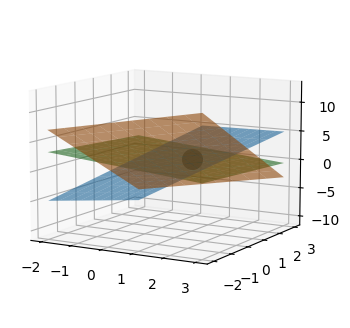

In [13]:
x = np.linspace(-2,3,10)
y = np.linspace(-2,3,10)
X,Y = np.meshgrid(x,y)

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d', elev=10, azim = -60)

for i in range(3):
    ax.plot_surface(X,Y,GetZ(A,b,X,Y,i),alpha=0.6)

ax.scatter(xsol[0],xsol[1],xsol[2],color='k',s=200)

In [14]:
import plotly.graph_objects as go

surfaces = []
for i in range(3):
    Z = GetZ(A, b, X, Y, i)
    surfaces.append(
        go.Surface(
            x=X, y=Y, z=Z,
            opacity=0.4,
            colorscale='Viridis',
            showscale=False,
            name=f"Plano {i+1}"
        )
    )

fig = go.Figure(data=surfaces)

point = go.Scatter3d(
    x=[xsol[0]], y=[xsol[1]], z=[xsol[2]],
    mode='markers+text',
    text=[f"sol: ({xsol[0]:.3f}, {xsol[1]:.3f}, {xsol[2]:.3f})"],
    textposition="top center",
    marker=dict(size=3),
    name="Solución"
)

fig.add_trace(point)
fig.show()